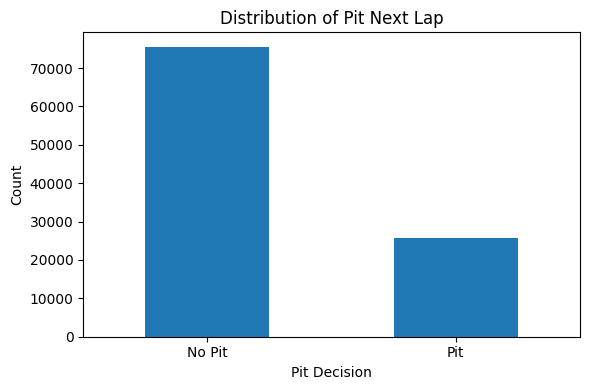

<Figure size 600x400 with 0 Axes>

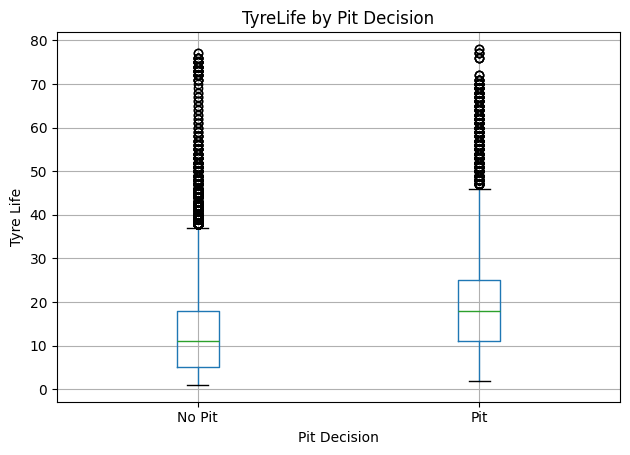

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("dataset/f1_strategy_dataset_v4.csv")

# -----------------------------
# Basic cleaning
# -----------------------------
# Drop rows with missing values in columns used for plotting
plot_cols = [
    "PitNextLap",
    "TyreLife",
    "LapNumber",
    "LapTime_Delta",
    "LapTime (s)",
    "RaceProgress"
]
df = df.dropna(subset=[col for col in plot_cols if col in df.columns])

# Make sure target is numeric if needed
df["PitNextLap"] = df["PitNextLap"].astype(int)

# Optional: create readable labels
df["PitLabel"] = df["PitNextLap"].map({0: "No Pit", 1: "Pit"})

# -----------------------------
# 1. Bar Chart: PitNextLap distribution
# -----------------------------
pit_counts = df["PitLabel"].value_counts()

plt.figure(figsize=(6, 4))
pit_counts.plot(kind="bar")
plt.title("Distribution of Pit Next Lap")
plt.xlabel("Pit Decision")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Boxplot: TyreLife grouped by PitNextLap
# -----------------------------
plt.figure(figsize=(6, 4))
df.boxplot(column="TyreLife", by="PitLabel")
plt.title("TyreLife by Pit Decision")
plt.suptitle("")  # removes automatic pandas subtitle
plt.xlabel("Pit Decision")
plt.ylabel("Tyre Life")
plt.tight_layout()
plt.show()

# # -----------------------------
# # 3. Scatter Plot: TyreLife vs LapTime_Delta
# # -----------------------------
# pit_df = df[df["PitNextLap"] == 1]
# no_pit_df = df[df["PitNextLap"] == 0]

# plt.figure(figsize=(7, 5))
# plt.scatter(no_pit_df["TyreLife"], no_pit_df["LapTime_Delta"], alpha=0.3, label="No Pit")
# plt.scatter(pit_df["TyreLife"], pit_df["LapTime_Delta"], alpha=0.5, label="Pit")
# plt.title("TyreLife vs LapTime_Delta")
# plt.xlabel("TyreLife")
# plt.ylabel("LapTime_Delta")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # -----------------------------
# # 4. Histogram: TyreLife distribution
# # -----------------------------
# plt.figure(figsize=(6, 4))
# plt.hist(df["TyreLife"], bins=30)
# plt.title("Histogram of TyreLife")
# plt.xlabel("TyreLife")
# plt.ylabel("Frequency")
# plt.tight_layout()
# plt.show()

# # -----------------------------
# # 5. Line Plot: Average lap time across lap number
# # -----------------------------
# avg_lap_time = df.groupby("LapNumber")["LapTime (s)"].mean()

# plt.figure(figsize=(8, 5))
# plt.plot(avg_lap_time.index, avg_lap_time.values)
# plt.title("Average Lap Time by Lap Number")
# plt.xlabel("Lap Number")
# plt.ylabel("Average Lap Time (s)")
# plt.tight_layout()
# plt.show()

# # -----------------------------
# # 6. Correlation Heatmap (manual with matplotlib)
# # -----------------------------
# numeric_cols = [
#     "LapNumber",
#     "TyreLife",
#     "Position",
#     "LapTime (s)",
#     "LapTime_Delta",
#     "Cumulative_Degradation",
#     "RaceProgress",
#     "Normalized_TyreLife",
#     "Position_Change",
#     "PitNextLap"
# ]

# existing_numeric_cols = [col for col in numeric_cols if col in df.columns]
# corr = df[existing_numeric_cols].corr()

# plt.figure(figsize=(8, 6))
# plt.imshow(corr, interpolation="nearest", aspect="auto")
# plt.colorbar()
# plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
# plt.yticks(range(len(corr.columns)), corr.columns)
# plt.title("Correlation Heatmap")
# plt.tight_layout()
# plt.show()

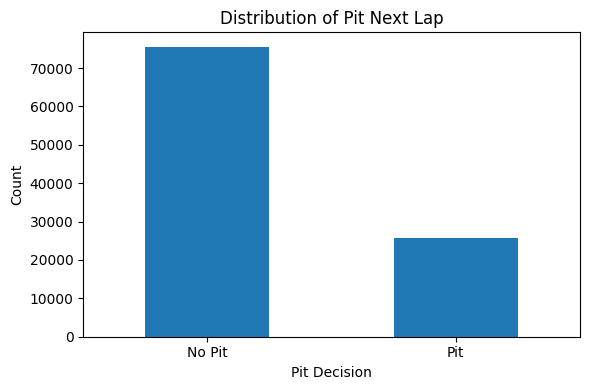

In [5]:
pit_counts = df["PitLabel"].value_counts()

plt.figure(figsize=(6, 4))
pit_counts.plot(kind="bar")
plt.title("Distribution of Pit Next Lap")
plt.xlabel("Pit Decision")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("figure1_pit_distribution.png", dpi=300) 
plt.show()

<Figure size 600x400 with 0 Axes>

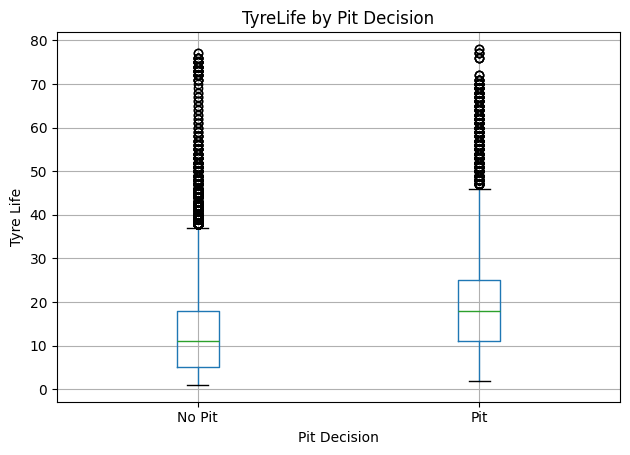

In [6]:
plt.figure(figsize=(6, 4))
df.boxplot(column="TyreLife", by="PitLabel")

plt.title("TyreLife by Pit Decision")
plt.suptitle("")
plt.xlabel("Pit Decision")
plt.ylabel("Tyre Life")

plt.tight_layout()
plt.savefig("figure2_tyrelife_boxplot.png", dpi=300) 
plt.show()